### Zadanie 13

In [146]:
from sklearn.linear_model import LinearRegression
import pandas as pd
import numpy as np
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.inspection import permutation_importance

In [6]:
housing = fetch_california_housing()
X, y = housing.data, housing.target
df_og = pd.DataFrame(X, columns=housing.feature_names)
df_og

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25
...,...,...,...,...,...,...,...,...
20635,1.5603,25.0,5.045455,1.133333,845.0,2.560606,39.48,-121.09
20636,2.5568,18.0,6.114035,1.315789,356.0,3.122807,39.49,-121.21
20637,1.7000,17.0,5.205543,1.120092,1007.0,2.325635,39.43,-121.22
20638,1.8672,18.0,5.329513,1.171920,741.0,2.123209,39.43,-121.32


In [172]:
df_feat = df_og.copy()
df_feat['IncRooms'] = df_feat.MedInc * df_feat.AveRooms
df_feat['BedrmsRooms'] = df_feat.AveBedrms / df_feat.AveRooms
df_feat['HouseAge_bin'] = pd.cut(df_feat.HouseAge, bins=4, labels=[1, 2, 3, 4])
df_feat["MedInc"]  = np.sqrt(df_feat.MedInc)
for c in ["Population", "AveOccup", "AveRooms", "AveBedrms", "MedInc"]:
    df_feat[c + "_log"] = np.log1p(df_feat[c])


df_feat

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,IncRooms,BedrmsRooms,HouseAge_bin,Population_log,AveOccup_log,AveRooms_log,AveBedrms_log,MedInc_log
0,2.885342,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,58.144254,0.146591,4,5.777652,1.268511,2.077455,0.704982,1.357211
1,2.881215,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,51.785271,0.155797,2,7.784057,1.134572,1.979364,0.678988,1.356148
2,2.693956,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,60.150315,0.129516,4,6.208590,1.335596,2.228738,0.729212,1.306698
3,2.375521,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,32.827897,0.184458,4,6.326149,1.266369,1.919471,0.729025,1.216550
4,1.961173,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,24.161264,0.172096,4,6.338594,1.157342,1.985385,0.732888,1.085586
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20635,1.249120,25.0,5.045455,1.133333,845.0,2.560606,39.48,-121.09,7.872423,0.224625,2,6.740519,1.269931,1.799307,0.757686,0.810539
20636,1.599000,18.0,6.114035,1.315789,356.0,3.122807,39.49,-121.21,15.632365,0.215208,2,5.877736,1.416534,1.962070,0.839751,0.955127
20637,1.303840,17.0,5.205543,1.120092,1007.0,2.325635,39.43,-121.22,8.849423,0.215173,2,6.915723,1.201661,1.825443,0.751460,0.834578
20638,1.366455,18.0,5.329513,1.171920,741.0,2.123209,39.43,-121.32,9.951266,0.219892,2,6.609349,1.138861,1.845223,0.775611,0.861393


In [164]:
def model_score(df, y):
    df_sc = df.copy()
    X_train, X_test, y_train, y_test = train_test_split(df_sc, y, test_size=0.2, random_state=42)

    scaler = StandardScaler()
    X_train_scale = scaler.fit_transform(X_train)
    X_test_scale = scaler.transform(X_test)

    model = LinearRegression().fit(X_train_scale, y_train)
    train_score = model.score(X_train_scale, y_train)
    test_score = model.score(X_test_scale, y_test)
    perm = permutation_importance(model, X_test_scale, y_test, scoring="r2", n_repeats=20, random_state=42)

    return train_score, test_score, perm

scores_og = model_score(df_og, y)
print(f"Train R2 score: {scores_og[0]:.5f}\nTest R2 score: {scores_og[1]:.5f}")

Train R2 score: 0.61255
Test R2 score: 0.57579


In [170]:
scores_feat = model_score(df_feat, y)
print(f"Train R2 score: {scores_feat[0]:.5f}\nTest R2 score: {scores_feat[1]:.5f}")
print(f'Diff:\n Train R2 score: {(scores_feat[0]-scores_og[0])/scores_feat[0]:.3f}%\n Test R2 score: {(scores_feat[1]-scores_og[1])/scores_feat[1]:.3f}%')

Train R2 score: 0.67682
Test R2 score: 0.62922
Diff:
 Train R2 score: 0.095%
 Test R2 score: 0.085%


<Axes: xlabel='importance', ylabel='feature'>

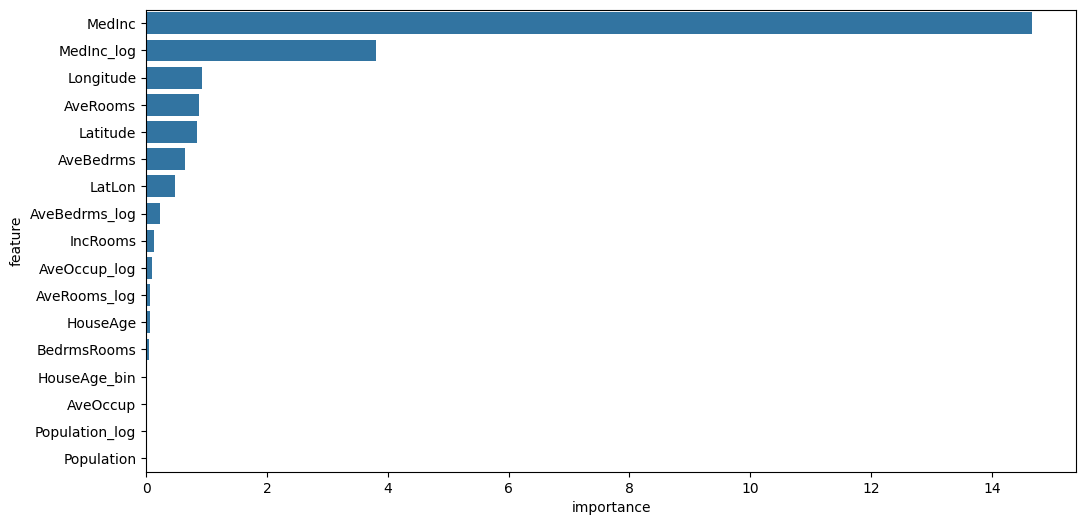

In [171]:
feature_importance = pd.DataFrame({
    "feature": df_feat.columns,
    "importance": scores_feat[2].importances_mean
}).sort_values("importance", ascending=False)

plt.figure(figsize=(12, 6))
sns.barplot(data=feature_importance, x='importance', y='feature')
